In [13]:
!pip install protobuf==3.20.3

*Requirement*

In [ ]:
import os
import gc
import random
import warnings
warnings.filterwarnings('ignore') # Tắt các cảnh báo không cần thiết

# --- 3. XỬ LÝ DỮ LIỆU & ẢNH ---
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 4. MACHINE LEARNING (SKLEARN) ---
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- 5. DEEP LEARNING (TENSORFLOW / KERAS) ---
import tensorflow as tf
from tensorflow.keras import backend as K # Dùng cho hàm focal_loss
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Input, 
    Conv2D, 
    MaxPooling2D, 
    Flatten, 
    Dense, 
    Dropout, 
    BatchNormalization
)
from tensorflow.keras.callbacks import (
    EarlyStopping, 
    ModelCheckpoint, 
    ReduceLROnPlateau
)


# Load data
Lấy dữ liệu từ nhánh data, dữ liệu đã được làm sạch và chuẩn hóa nên chỉ thực hiện upload, nếu cần xử lí thêm sẽ bổ sung sau

In [ ]:
IMG_SIZE = 150
BATCH_SIZE = 32
EPOCHS = 20
KAGGLE_PATH = '/kaggle/input/processed-dip/processed/train'
LOCAL_PATH = os.path.join('..', 'data', 'processed', 'train')

if os.path.exists(KAGGLE_PATH):
    print("MÔI TRƯỜNG: KAGGLE GPU")
    dataset_path = KAGGLE_PATH
elif os.path.exists(LOCAL_PATH):
    print("MÔI TRƯỜNG: LOCAL PC")
    dataset_path = LOCAL_PATH
else:
    raise FileNotFoundError("❌ Không tìm thấy dữ liệu! Hãy Add Data trên Kaggle.")

print(f"Đang đọc dữ liệu từ: {dataset_path}")
data = []
labels = []
categories = ['NORMAL', 'PNEUMONIA']

for category in categories:
    path = os.path.join(dataset_path, category)
    class_num = categories.index(category)
    try:
        files = os.listdir(path)
        if 'kaggle' not in dataset_path.lower():
            files = files[:100]
            
        for img_name in files:
            try:
                img_path = os.path.join(path, img_name)
                img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img_array is not None:
                    resized_arr = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                    data.append(resized_arr)
                    labels.append(class_num)
            except Exception as e:
                pass
    except Exception as e:
        print(f"Lỗi đọc folder {category}: {e}")

print(f"Đã load xong: {len(data)} ảnh.")

MÔI TRƯỜNG: KAGGLE GPU
Đang đọc dữ liệu từ: /kaggle/input/processed-img-2/processed/train
Đã load xong: 17601 ảnh.


In [ ]:
X = np.array(data)
y = np.array(labels)

del data
del labels
gc.collect()

X = X / 255.0
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"📊 Train set: {X_train.shape}")
print(f"📊 Val set:   {X_val.shape}")
class_weights_vals = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

weights_dict = dict(enumerate(class_weights_vals))

print("-" * 30)
print(f"Các lớp (Labels): {np.unique(y_train)}")
print(f"Trọng số đã tính (Class Weights): {weights_dict}")
print("-" * 30)

📊 Train set: (14080, 150, 150, 1)
📊 Val set:   (3521, 150, 150, 1)
------------------------------
Các lớp (Labels): [0 1]
Trọng số đã tính (Class Weights): {0: 1.2098298676748582, 1: 0.8521970705725699}
------------------------------


# CNN 

Xây dựng mô hình

In [ ]:
model = Sequential()

model.add(Input(shape=(IMG_SIZE, IMG_SIZE, 1)))

# Lớp 1
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Lớp 2
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Lớp 3
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Lớp Phẳng
model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
# Lớp Neuron
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5)) # Tránh Overfitting
model.add(Dense(1, activation='sigmoid'))

def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1 - K.epsilon())
        cross_entropy = -y_true * K.log(y_pred)
        weight = alpha * y_true * K.pow((1 - y_pred), gamma)
        loss = weight * cross_entropy
        return K.sum(loss, axis=1) 
    return focal_loss_fixed
    
model.compile(
    optimizer='adam', 
    loss=tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0, apply_class_balancing=True),
    metrics=['accuracy', 'Precision', 'Recall']
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    10,617,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,007,617 (41.99 MB)

 Trainable params: 11,006,657 (41.99 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    ModelCheckpoint('cnn_pneumonia_model.keras', save_best_only=True, monitor='val_accuracy'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print("Bắt đầu train")
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks
)

Bắt đầu train
Epoch 1/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - accuracy: 0.8965 - loss: 1.5538 - val_accuracy: 0.5856 - val_loss: 25.0674 - learning_rate: 0.0010
Epoch 2/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.9623 - loss: 0.1075 - val_accuracy: 0.7844 - val_loss: 0.5942 - learning_rate: 0.0010
Epoch 3/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.9693 - loss: 0.0838 - val_accuracy: 0.9801 - val_loss: 0.0540 - learning_rate: 0.0010
Epoch 4/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.9789 - loss: 0.0690 - val_accuracy: 0.9847 - val_loss: 0.0462 - learning_rate: 0.0010
Epoch 5/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.9747 - loss: 0.0761 - val_accuracy: 0.9767 - val_loss: 0.0701 - learning_rate: 0.0010
Epoch 6/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.9853 - loss: 0.0460 - val_accuracy: 0.9776 - val_loss: 0.0665 - learning_rate: 0.0010
Epoch 7/20
439/440 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accura

In [ ]:
print("🔄 Đang tải model tốt nhất từ file...")
try:
    model_best = load_model('cnn_pneumonia_model.keras')
    print("✅ Đã tạo xong biến 'model_best'!")
except:
    print("⚠️ Không tìm thấy file. Dùng tạm biến 'model' vừa train xong.")
    model_best = model 

🔄 Đang tải model tốt nhất từ file...
✅ Đã tạo xong biến 'model_best'!


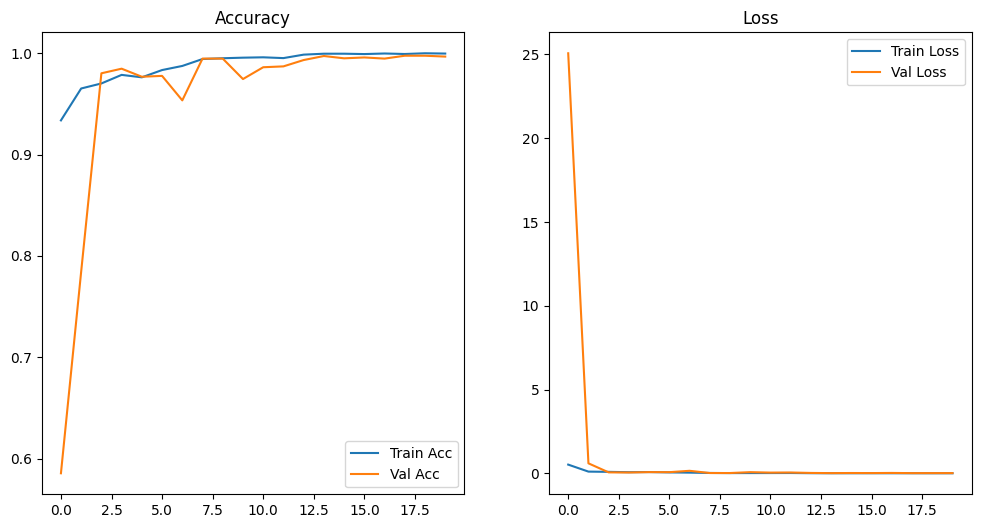

File model đã được lưu: cnn_pneumonia_model.keras


In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Acc')
plt.plot(val_acc, label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

print("File model đã được lưu: cnn_pneumonia_model.keras")

In [ ]:
TEST_PATH = '/kaggle/input/data-test/klasifikasi_pneumonia/test'
IMG_SIZE = 150

FOLDERS_PNEUMONIA = ['PNEUMONIA (BAKTERI)', 'PNEUMONIA (VIRUS)']
FOLDER_NORMAL = 'NORMAL' 

X_test_new = []
y_test_new = []

print(f" Đang đọc dữ liệu từ: {TEST_PATH}")

if not os.path.exists(TEST_PATH):
    print(f" LỖI: Không tìm thấy đường dẫn {TEST_PATH}")
else:
    for sub_folder in FOLDERS_PNEUMONIA:
        path = os.path.join(TEST_PATH, sub_folder)
        if os.path.exists(path):
            files = os.listdir(path)
            print(f"   -> Tìm thấy folder '{sub_folder}': {len(files)} ảnh")
            count = 0
            for img_name in files:
                try:
                    img_path = os.path.join(path, img_name)
                    img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                    if img_array is not None:
                        resized_arr = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                        X_test_new.append(resized_arr)
                        y_test_new.append(1) 
                        count += 1
                except: pass
            print(f"      Đã nạp: {count} ảnh.")
        else:
            print(f"⚠️ Không thấy folder: {sub_folder} (Có thể bỏ qua nếu không quan trọng)")

    path_normal = os.path.join(TEST_PATH, FOLDER_NORMAL)
    if os.path.exists(path_normal):
        files = os.listdir(path_normal)
        print(f"   -> Tìm thấy folder '{FOLDER_NORMAL}': {len(files)} ảnh")
        for img_name in files:
            try:
                img_path = os.path.join(path_normal, img_name)
                img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img_array is not None:
                    resized_arr = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                    X_test_new.append(resized_arr)
                    y_test_new.append(0) 
            except: pass
    else:
        print(f"ℹ️ Lưu ý: Không tìm thấy folder '{FOLDER_NORMAL}' trong tập test này.")

    # 3. CHUẨN HÓA DỮ LIỆU
    if len(X_test_new) > 0:
        X_test_new = np.array(X_test_new).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
        X_test_new = X_test_new / 255.0 
        y_test_new = np.array(y_test_new)
        
        print("\n" + "="*40)
        print(f"✅ THÀNH CÔNG! Tổng số ảnh test load được: {len(X_test_new)}")
        print(f"   - Số ảnh Pneumonia (Nhãn 1): {np.sum(y_test_new == 1)}")
        print(f"   - Số ảnh Normal (Nhãn 0):    {np.sum(y_test_new == 0)}")
        print("="*40)
    else:
        print("VẪN KHÔNG LOAD ĐƯỢC ẢNH NÀO. Vui lòng kiểm tra lại đường dẫn chính xác!")

   -> Đang đọc folder NORMAL: 231 ảnh
   -> Đang đọc folder PNEUMONIA: 387 ảnh
✅ Đã chuẩn bị xong dữ liệu: (618, 150, 150, 1)


In [ ]:
print("🔄 Đang tải model...")

try:
    model_best = load_model('cnn_pneumonia_model.keras')
    print("✅ Đã load thành công model từ file 'cnn_pneumonia_model.keras'")
except:
    print("⚠️ Không tìm thấy file model đã lưu!")
    if 'model' in globals():
        print("-> Đang dùng tạm model vừa train xong trong RAM.")
        model_best = model
    else:
        print("❌ LỖI: Không có model nào để chấm điểm cả.")

🔄 Đang tải model...
✅ Đã load thành công model từ file 'cnn_pneumonia_model.keras'


⏳ Đang chấm bài (Predicting)...
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step

🏆 KẾT QUẢ CUỐI CÙNG (TEST ACCURACY): 82.52%
Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.97      0.55      0.70       231
   PNEUMONIA       0.79      0.99      0.88       387

    accuracy                           0.83       618
   macro avg       0.88      0.77      0.79       618
weighted avg       0.85      0.83      0.81       618



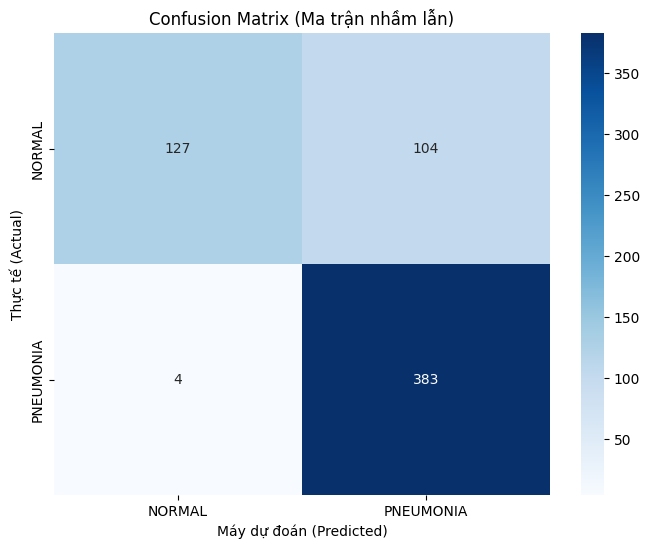

In [ ]:
try:
    del X_train, X_val, y_train, y_val
    del model 
    gc.collect()
    print("✅ Đã giải phóng RAM để chuẩn bị train Gatekeeper!")
except:
    pass

In [ ]:
# ----------------------------------------------------------------
# TRAIN MODEL GÁC CỔNG (PHIÊN BẢN NÂNG CẤP - CHỐNG NHẦM ANIME)
# ----------------------------------------------------------------
import cv2
import numpy as np
import os
import gc
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

# 1. CẤU HÌNH
IMG_SIZE = 150

# --- ĐƯỜNG DẪN DỮ LIỆU ---
# Ảnh tự nhiên (Xe, hoa, chó, mèo...)
NON_XRAY_PATH = '/kaggle/input/natural-images/natural_images/' 
# Ảnh Anime (QUAN TRỌNG: Bạn cần Add Data "Anime Faces" trên Kaggle vào)
# Nếu chưa add, bạn có thể bỏ qua, nhưng model sẽ kém thông minh hơn với ảnh hoạt hình
ANIME_PATH = '/kaggle/input/anime-faces/data/' 

# Ảnh X-ray chuẩn (Lấy từ tập train đã xử lý)
XRAY_PATH = '/kaggle/input/processed-dip/processed/train/NORMAL'

data_gk = []
labels_gk = [] # 0: Rác (Non-Xray), 1: X-Quang

print("🔄 Đang chuẩn bị dữ liệu 'Khó' cho Gatekeeper...")

# ===========================
# PHẦN 1: LOAD DỮ LIỆU RÁC (LABEL 0)
# ===========================

# 1.1. Load Ảnh Tự Nhiên (Natural Images) ~ 500 ảnh
try:
    count = 0
    if os.path.exists(NON_XRAY_PATH):
        sub_folders = os.listdir(NON_XRAY_PATH)
        for folder in sub_folders:
            path = os.path.join(NON_XRAY_PATH, folder)
            if os.path.isdir(path):
                for img_name in os.listdir(path):
                    if count >= 500: break 
                    try:
                        img_path = os.path.join(path, img_name)
                        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                        if img is not None:
                            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                            data_gk.append(img)
                            labels_gk.append(0)
                            count += 1
                    except: pass
    print(f"   -> Đã load {count} ảnh Tự nhiên (Natural).")
except:
    print("⚠️ Lỗi load ảnh Natural Images.")

# 1.2. Load Ảnh Anime (QUAN TRỌNG ĐỂ CHỐNG NHẦM) ~ 500 ảnh
try:
    count_anime = 0
    # Kiểm tra xem có dataset anime không, nếu không có thì tìm thư mục khác hoặc bỏ qua
    target_anime_path = ANIME_PATH if os.path.exists(ANIME_PATH) else None
    
    if target_anime_path:
        # Dataset Anime thường không chia folder con, hoặc tùy dataset
        # Đoạn này duyệt đệ quy để tìm ảnh cho chắc
        for root, dirs, files in os.walk(target_anime_path):
            if count_anime >= 500: break
            for img_name in files:
                if count_anime >= 500: break
                try:
                    img_path = os.path.join(root, img_name)
                    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                    if img is not None:
                        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                        data_gk.append(img)
                        labels_gk.append(0) # Vẫn là nhãn 0 (Rác)
                        count_anime += 1
                except: pass
        print(f"   -> Đã load {count_anime} ảnh Anime (Để model học cách phân biệt).")
    else:
        print("⚠️ Không tìm thấy dataset Anime. Model có thể vẫn bị nhầm với ảnh hoạt hình đen trắng.")
        print("   (Khuyên dùng: Add dataset 'Anime Faces' vào Kaggle)")
except: 
    print("⚠️ Lỗi khi load ảnh Anime.")

# ===========================
# PHẦN 2: LOAD DỮ LIỆU PHỔI (LABEL 1)
# ===========================
# Load khoảng 1000 ảnh X-QUANG để cân bằng (500 Natural + 500 Anime)
try:
    files = os.listdir(XRAY_PATH)[:1000] 
    count_xray = 0
    for img_name in files:
        try:
            img_path = os.path.join(XRAY_PATH, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                data_gk.append(img)
                labels_gk.append(1)
                count_xray += 1
        except: pass
    print(f"   -> Đã load {count_xray} ảnh X-Quang mẫu.")
except:
    print("⚠️ Lỗi load ảnh X-ray mẫu.")

# ===========================
# PHẦN 3: TRAIN MODEL NÂNG CẤP
# ===========================

# Convert & Train Test Split
X_gk = np.array(data_gk).reshape(-1, IMG_SIZE, IMG_SIZE, 1) / 255.0
y_gk = np.array(labels_gk)

print(f"\n📊 Tổng dữ liệu Gatekeeper: {len(X_gk)} ảnh")
print(f"   - Rác (Natural + Anime): {np.sum(y_gk==0)}")
print(f"   - X-Quang chuẩn: {np.sum(y_gk==1)}")

X_train_gk, X_val_gk, y_train_gk, y_val_gk = train_test_split(X_gk, y_gk, test_size=0.2, random_state=42)

# KIẾN TRÚC MODEL MẠNH HƠN (Deeper CNN)
model_gk = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    # Block 2
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    # Block 3 (Thêm chiều sâu để hiểu cấu trúc xương)
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Tắt 50% nơ-ron ngẫu nhiên để chống học vẹt
    Dense(1, activation='sigmoid')
])

# Dùng Learning Rate nhỏ (0.0001) để model học kỹ hơn
model_gk.compile(optimizer=Adam(learning_rate=0.0001), 
                 loss='binary_crossentropy', 
                 metrics=['accuracy'])

print("\n⏳ Bắt đầu train Gatekeeper (10 Epochs - Chế độ kỹ lưỡng)...")
model_gk.fit(X_train_gk, y_train_gk, 
             epochs=10, 
             validation_data=(X_val_gk, y_val_gk), 
             verbose=1)

model_gk.save('gatekeeper_model.keras')
print("✅ Đã lưu model Gatekeeper nâng cấp: gatekeeper_model.keras")

# Dọn dẹp RAM
del data_gk, X_gk, X_train_gk
gc.collect()

Đang xem xét ảnh: person135_bacteria_646.jpeg


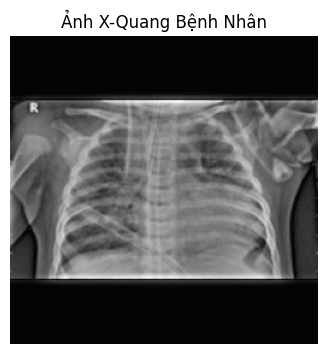

------------------------------
KẾT QUẢ CHẨN ĐOÁN CỦA CNN:
KẾT LUẬN: VIÊM PHỔI (PNEUMONIA)
Độ tin cậy: 100.00%
------------------------------


In [ ]:
if 'model_best' not in globals():
    print("🔄 Đang tải lại model tốt nhất từ file...")
    try:
        model_best = load_model('cnn_pneumonia_model.keras') 
        print("Đã load xong model_best!")
    except:
        print("Không tìm thấy file model. Đang dùng tạm biến 'model' hiện tại.")
        if 'model' in globals():
            model_best = model
        else:
            raise ValueError("Lỗi: Không tìm thấy model nào cả! Bạn cần train hoặc upload file model trước.")

print("⏳ Đang chấm bài (Predicting)...")

try:
    predictions = model_best.predict(X_test_new)
except NameError:
    print("Lỗi: Biến 'X_test_new' chưa được tạo. Bạn hãy chạy lại Cell load dữ liệu Test ở trên trước nhé!")
    raise
y_pred = (predictions >= 0.5).astype(int)

try:
    acc = accuracy_score(y_test_new, y_pred)
    
    print("\n" + "="*40)
    print(f"KẾT QUẢ CUỐI CÙNG (TEST ACCURACY): {acc*100:.2f}%")
    print("="*40)

    print("Classification Report:")
    print(classification_report(y_test_new, y_pred, target_names=['NORMAL', 'PNEUMONIA']))
    cm = confusion_matrix(y_test_new, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['NORMAL', 'PNEUMONIA'], 
                yticklabels=['NORMAL', 'PNEUMONIA'])
    plt.xlabel('Máy dự đoán (Predicted)')
    plt.ylabel('Thực tế (Actual)')
    plt.title('Confusion Matrix (Ma trận nhầm lẫn)')
    plt.show()

except NameError:
    print("Lỗi: Biến 'y_test_new' chưa có. Hãy chạy lại Cell load dữ liệu Test.")

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import io
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

def predict_uploaded_image(file_content, filename):
    nparr = np.frombuffer(file_content, np.uint8)
    img = cv2.imdecode(nparr, cv2.IMREAD_GRAYSCALE) 
    
    if img is None:
        print(f"❌ Lỗi: Không đọc được file {filename}")
        return

    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap='gray')
    plt.title(f"Ảnh bạn vừa up: {filename}")
    plt.axis('off')
    plt.show()

    # Resize chuẩn 150x150
    img_resized = cv2.resize(img, (150, 150))
    img_input = np.array(img_resized).reshape(1, 150, 150, 1) / 255.0

    # --- BƯỚC 1: GATEKEEPER (Kiểm tra xem phải X-Quang không) ---
    # Tự động load model nếu chưa có
    global model_gatekeeper
    try:
        if 'model_gatekeeper' not in globals():
            model_gatekeeper = load_model('gatekeeper_model.keras')
        
        is_xray = model_gatekeeper.predict(img_input, verbose=0)[0][0]
        print(f"🔍 Kiểm tra loại ảnh (Gatekeeper Score): {is_xray:.4f}")
        
        if is_xray < 0.8:
            print("⛔ CẢNH BÁO: Hệ thống phát hiện đây KHÔNG PHẢI ảnh X-Quang phổi.")
            print("   (Vui lòng upload đúng ảnh y tế để có kết quả chính xác)")
            return 
    except:
        print("⚠️ Không tìm thấy model Gatekeeper, bỏ qua bước lọc ảnh rác.")

    # --- BƯỚC 2: CHẨN ĐOÁN (CNN Chính) ---
    global model_best
    try:
        if 'model_best' not in globals():
            model_best = load_model('cnn_pneumonia_model.keras')
            
        pred = model_best.predict(img_input, verbose=0)[0][0]
        
        print("-" * 40)
        if pred >= 0.5:
            conf = pred * 100
            print(f"🚨 KẾT LUẬN: VIÊM PHỔI (PNEUMONIA)")
            print(f"📊 Độ tự tin: {conf:.2f}%")
        else:
            conf = (1 - pred) * 100
            print(f"✅ KẾT LUẬN: BÌNH THƯỜNG (NORMAL)")
            print(f"📊 Độ tự tin: {conf:.2f}%")
        print("-" * 40)
        
    except Exception as e:
        print(f"❌ Lỗi khi chạy model chính: {e}")

# 2. Tạo giao diện nút bấm
upload_btn = widgets.FileUpload(
    accept='image/*',  # Chỉ chấp nhận file ảnh
    multiple=False,    # Upload từng cái một
    description='Tải ảnh lên'
)

out = widgets.Output()

def on_upload_change(change):
    # Xóa kết quả cũ
    out.clear_output()
    
    # Lấy file vừa upload
    # Cấu trúc của widget thay đổi tùy version, đây là cách xử lý chung
    if not change['new']: return
    
    with out:
        try:
            if isinstance(change['new'], tuple) or isinstance(change['new'], list):
                item = change['new'][0]
                content = item['content']
                filename = item['name']
            else:
                # Xử lý cho version cũ hơn (nếu có)
                key = list(change['new'].keys())[0]
                content = change['new'][key]['content']
                filename = change['new'][key]['metadata']['name']
                
            print(f"🔄 Đang xử lý ảnh: {filename}...")
            predict_uploaded_image(content, filename)
            
        except Exception as e:
            print(f"Lỗi widget: {e}")
upload_btn.observe(on_upload_change, names='value')
print("👇 BẤM VÀO NÚT DƯỚI ĐỂ CHỌN ẢNH TỪ MÁY TÍNH CỦA BẠN 👇")
display(upload_btn)
display(out)